<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_4_1_MLR_Ames_Part1_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames Iowa: Part 1,  Data Cleaning

Author: Brad Sheese
___

## Purpose of this Notebook
This notebook demonstrates manual cleaning of a real-world dataset. The intent of the cleaning is to prepare the dataset for inference, wherein we are interested in examining individual coefficients of features in the model.

### Data Cleaning, Under and Over Cleaning
The primary goal of data cleaning is to transform messy, raw data into a structured, model-ready format that maximizes true predictive signals and minimizes disruptive noise. This involves transforming the data in different ways. The trick is that we need to do this  without distorting the underlying reality of the information.

Achieving this balance requires navigating the dual pitfalls of under-cleaning and over-cleaning. Under-cleaning leaves too much chaos in the dataset, such as unhandled missing values, unencoded strings, extreme outliers, or highly collinear features, which can cause machine learning algorithms to crash, fail to converge, or overfit on structural errors. Conversely, over-cleaning stems from an overzealous attempt to simplify or shrink the data, resulting in the destruction of valuable information through the aggressive dropping of features, the clumsy grouping of highly distinct categories into generic buckets, or inappropriate binarization of continuous variables. You always need to balance these two when considering just how much of your data to clean.

## Data for this Exercise
**Data Source:** http://jse.amstat.org/v19n3/decock/AmesHousing.txt

The Ames housing dataset, compiled by Dean De Cock in 2011, is a comprehensive collection of information detailing nearly every aspect of residential property sales in Ames, Iowa, from 2006 to 2010. It consists of approximately 2,930 observations and 79 explanatory variables, ranging from house quality and neighborhood to square footage and number of bathrooms, which are used to predict the final "SalePrice" of each home.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Loading the dataframe
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'
df = pd.read_csv(url, sep='\t')

### We're going to do some preliminary cleaning here to make this notebook
### more approachable for beginners.

# Drop as recommended by the author of the dataset (unusual sales)
df = df[df["Gr Liv Area"] < 4000]

# Drop Identifiers. These are unique identifiers
df = df.drop(['Order', 'PID'], axis=1)

# Drop near-constant or highly sparse features to keep the dataset manageable for beginners
sparse_drops = ['Pool QC', 'Pool Area', 'Misc Feature', 'Misc Val', 'Alley', 'Fence']
constant_drops = ['Street', 'Utilities', 'Condition 2', 'Roof Matl', 'Heating', 'Low Qual Fin SF', '3Ssn Porch']

# We will also drop 'Garage Yr Blt' to simplify and avoid leakage
df = df.drop(sparse_drops + constant_drops + ['Garage Yr Blt'], axis=1, errors='ignore')

# Correct Data Types
# MSSubClass is a numeric code, not a magnitude. Convert to string so it's not treated as a continuous number.
df['MS SubClass'] = df['MS SubClass'].astype(str)

df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Lot Shape,Land Contour,Lot Config,Land Slope,Neighborhood,Condition 1,...,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,Screen Porch,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,IR1,Lvl,Corner,Gtl,NAmes,Norm,...,P,210,62,0,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Reg,Lvl,Inside,Gtl,NAmes,Feedr,...,Y,140,0,0,120,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,IR1,Lvl,Corner,Gtl,NAmes,Norm,...,Y,393,36,0,0,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Reg,Lvl,Corner,Gtl,NAmes,Norm,...,Y,0,0,0,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,IR1,Lvl,Inside,Gtl,Gilbert,Norm,...,Y,212,34,0,0,3,2010,WD,Normal,189900


# Missing Values

This is about observations where some variables are absent (NA, blank, null, etc.). Regression usually cannot use rows with missing predictor or outcome values unless you explicitly handle them. Missingness can also bias inference if it is systematic.

## Typical checks:
* How many values are missing?
* Which variables are affected?
* Is missingness random or patterned?

## Common remediation approaches:
1. Listwise deletion: Drop rows with missing values.
    * Good when: missingness is small, approximately random, sample size is large.
    * Risk: loss of power, potential bias.
2. Imputation: Fill in plausible values.
    * Examples: mean/median imputation, regression imputation, multiple imputation (preferred for inference).
    * For inference, multiple imputation is often favored because it preserves uncertainty better.


In [53]:
# this produces a Series wehn the index is the column anmes and values
# are the total count of missing values
missing_values = df.isnull().sum()

# Columns with missing values
columns_with_missing = missing_values[missing_values > 0]
print(f"Columns with missing values ({len(columns_with_missing)} of {df.shape[1]}):")

# The code columns_with_missing.empty checks if the pandas Series or DataFrame
# columns_with_missing is empty. It returns True if the object has no items,
# and False otherwise. In this context, columns_with_missing is a Series
# containing columns that have missing values, so columns_with_missing.empty
# would be True if there were no columns with missing values,
# and False if there were any.
if not columns_with_missing.empty:
    for col, count in columns_with_missing.items():
        print(f"  - {col}: {count} missing values, {round(count/df.shape[1])}% of total")
else:
    print("  None")

print("\n"+"-"*50+"\n")

# Columns without missing values, uncomment if you want to see
columns_without_missing = missing_values[missing_values == 0]
# print(f"Columns without missing values ({len(columns_without_missing)}):")
# if not columns_without_missing.empty:
#     for col in columns_without_missing.index:
#         print(f"  - {col}")
# else:
#     print("  None")

print(f'Percent of columns with missing values {round(len(columns_with_missing)/df.shape[1], 2)}%')

Columns with missing values (22 of 66):
  - Lot Frontage: 490 missing values, 7% of total
  - Mas Vnr Type: 1774 missing values, 27% of total
  - Mas Vnr Area: 23 missing values, 0% of total
  - Bsmt Qual: 80 missing values, 1% of total
  - Bsmt Cond: 80 missing values, 1% of total
  - Bsmt Exposure: 83 missing values, 1% of total
  - BsmtFin Type 1: 80 missing values, 1% of total
  - BsmtFin SF 1: 1 missing values, 0% of total
  - BsmtFin Type 2: 81 missing values, 1% of total
  - BsmtFin SF 2: 1 missing values, 0% of total
  - Bsmt Unf SF: 1 missing values, 0% of total
  - Total Bsmt SF: 1 missing values, 0% of total
  - Electrical: 1 missing values, 0% of total
  - Bsmt Full Bath: 2 missing values, 0% of total
  - Bsmt Half Bath: 2 missing values, 0% of total
  - Fireplace Qu: 1422 missing values, 22% of total
  - Garage Type: 157 missing values, 2% of total
  - Garage Finish: 159 missing values, 2% of total
  - Garage Cars: 1 missing values, 0% of total
  - Garage Area: 1 missing v

This particular data set has quite a bit of missing data. We won't fix this yet. To avoid data leakage between the train and test sets we will wait until after the splits are made to address this.  

---
# Coding Errors

These are mistakes in how data were recorded or imported.

Examples:
* Age recorded as 222
* Missing values recorded as 0 or -9999
* Decimal place errors (50000 vs 500000)
* Dates imported incorrectly
* String values interpreted as numbers or vice versa

Why it matters: Regression assumes variables mean what you think they mean. Coding mistakes can completely distort estimates.

Typical checks:
* Frequency tables
* Summary statistics
* Range checks
* Spot-checking raw records



In [54]:
# Temporarily set the display option to suppress scientific notation
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Generate and display the descriptive statistics for numeric columns
df_numerics = df.select_dtypes(include=np.number)
result = df_numerics.describe().T[['mean', 'min', 'max']]
print(result)

# Reset the display option to its default
pd.reset_option('display.float_format')

                    mean      min       max
Lot Frontage       69.02    21.00    313.00
Lot Area        10103.58  1300.00 215245.00
Overall Qual        6.09     1.00     10.00
Overall Cond        5.56     1.00      9.00
Year Built       1971.30  1872.00   2010.00
Year Remod/Add   1984.23  1950.00   2010.00
Mas Vnr Area      100.71     0.00   1600.00
BsmtFin SF 1      438.10     0.00   2288.00
BsmtFin SF 2       49.81     0.00   1526.00
Bsmt Unf SF       558.95     0.00   2336.00
Total Bsmt SF    1046.85     0.00   3206.00
1st Flr SF       1155.46   334.00   3820.00
2nd Flr SF        333.83     0.00   1862.00
Gr Liv Area      1493.98   334.00   3820.00
Bsmt Full Bath      0.43     0.00      3.00
Bsmt Half Bath      0.06     0.00      2.00
Full Bath           1.56     0.00      4.00
Half Bath           0.38     0.00      2.00
Bedroom AbvGr       2.85     0.00      8.00
Kitchen AbvGr       1.04     0.00      3.00
TotRms AbvGrd       6.43     2.00     14.00
Fireplaces          0.60     0.0

Inspecting the mins and maxs doesn't reveal any clearly out-of-bounds values. The mins are not negative. The maxs seem reasonable. The months and years sold, for example, are clearly within bounds.  

In [55]:
# Generate and display the descriptive statistics for non-numeric columns
df_non_numerics = df.select_dtypes(exclude = np.number)
result = df_non_numerics.describe()
result.T

,count,unique,top,freq
MS SubClass,2925,16,20,1078
MS Zoning,2925,7,RL,2268
Lot Shape,2925,4,Reg,1859
Land Contour,2925,4,Lvl,2631
Lot Config,2925,5,Inside,2138
Land Slope,2925,3,Gtl,2784
Neighborhood,2925,28,NAmes,443
Condition 1,2925,9,Norm,2519
Bldg Type,2925,5,1Fam,2420
House Style,2925,8,1Story,1480


No clearly wrong values here either. The number of unique values can sometimes alert you to errors. They all seem reasonable in this case.

---
# Outliers / data entry mistakes

These are observations that are unusually extreme. Some are real extreme values, some are errors. For our current analysis, using multiple linear regression for inference, this is particularly important because OLS regression is sensitive to extreme observations, especially high-leverage points.

## Types of outliers:
1. Response outliers: Extreme Y values.
2. Predictor outliers: Extreme X values.
3. Influential points: Observations that strongly affect coefficient estimates.

## Common diagnostics:
* calculated before modelling on the whole dataset:
    * Boxplots
* calculated after modeling on the training set only (we will do this in the next notebook):
    * Standardized residuals
    * Cook’s distance
    * Leverage values

## Remediation:
First, determine is the value plausible? Is it a recording mistake?
If it’s a true observation don’t automatically delete it, consider robust methods, assess influence diagnostics.




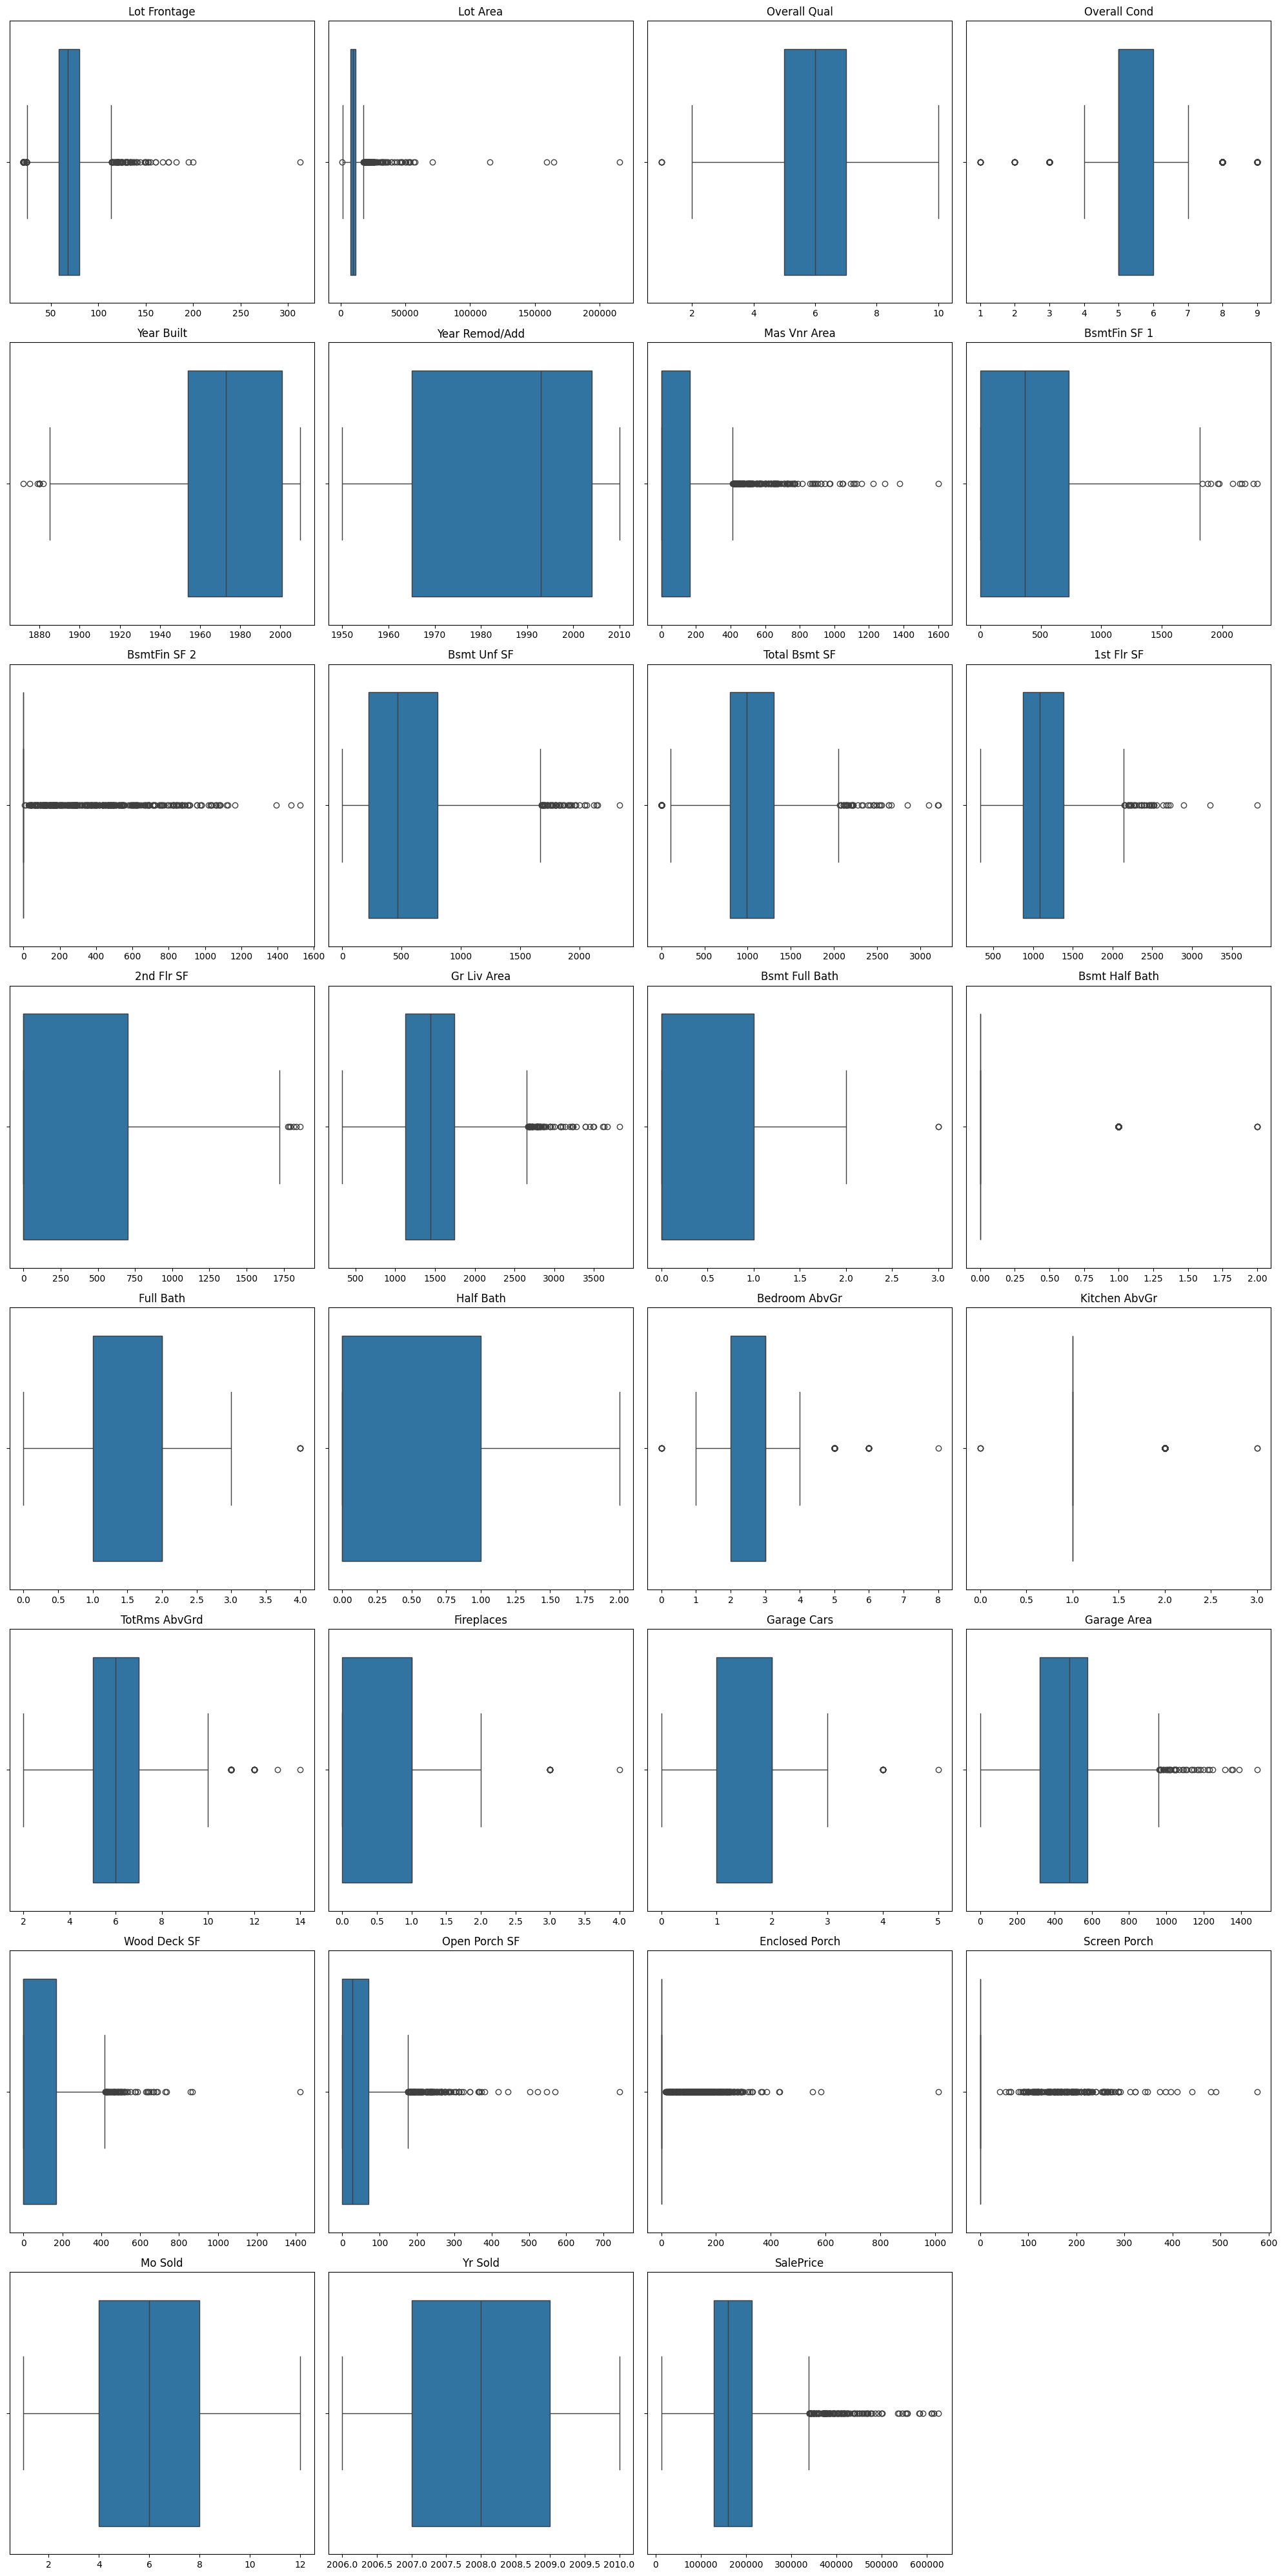

In [56]:
num_cols = len(df_numerics.columns)
num_rows = (num_cols + 3) // 4  # Calculate number of rows needed (4 columns per row)

fig, axes = plt.subplots(num_rows, 4, figsize=(20, 5 * num_rows)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(df_numerics.columns):
    sns.boxplot(data=df_numerics, x=col, ax=axes[i])
    axes[i].set_title(col) # Add title to each subplot
    axes[i].set_xlabel('') # Remove x-label from individual plots for compactness

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

The boxplots reveal both many outliers and non-normally distributed variables.


Notably, `SalePrice`, our outcome, has many outliers on the high end of housing prices.
Other variables of concern include:
`Lot Area`, `Gr Liv Area`, `Mas Vnr Area`, `Total Bsmt SF`. These can all be addressed to some degree through transformations.

It is important to address `SalePrice` in particular because highly skewed outcome distributions and extreme observations can disproportionately influence ordinary least squares (OLS) estimates, inflate residual variance, and violate modeling assumptions such as normally distributed and homoscedastic residuals.

Applying a transformation, such as a logarithmic transformation, can reduce skewness, stabilize variance, and improve the interpretability and reliability of inferential results.

---
# Variable transformations

Changing variables mathematically to better fit model assumptions or improve interpretability.

## Common transformations

* Log transformation
    * Useful for skewed variables, multiplicative relationships, diminishing returns.

* Square root transformation
    * Sometimes used for count-like variables.

* Polynomial terms
    * To model curves


## Why transformations matter for inference

Regression assumes linearity in parameters and  reasonably well-behaved residuals. Transformations can improve linearity, reduce heteroskedasticity, and stabilize variance.


## Important Note: Interpretation changes


Any kind of transform will change how that variable is subsequently interpreted. For example, in the current dataset a log-transform of `SalePrice` will mean that we must interpret our subsequent results in terms of the log-scale.

---

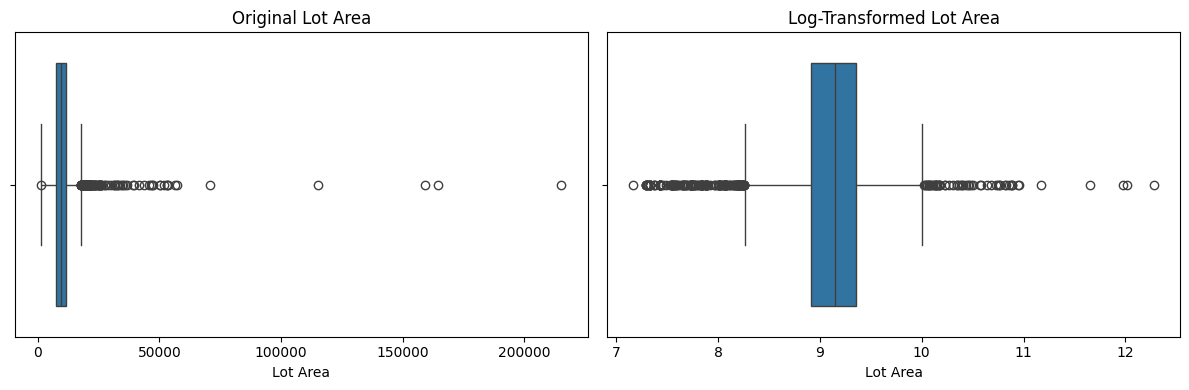

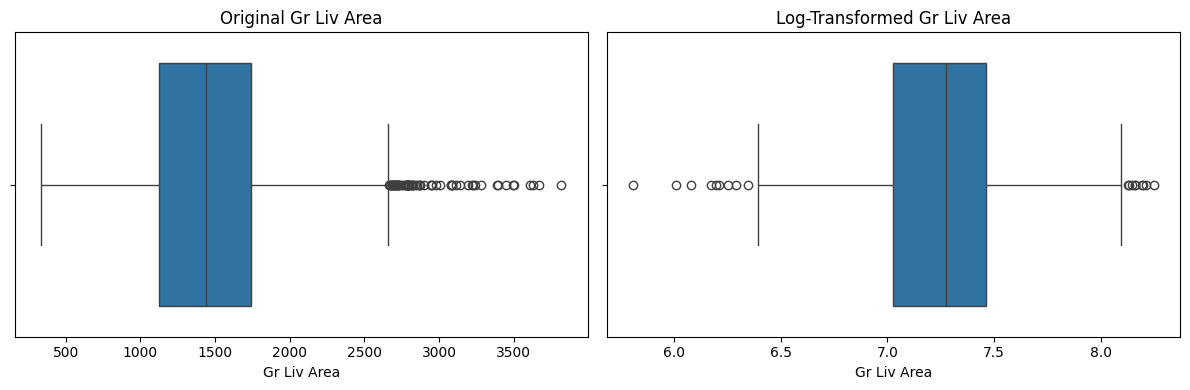

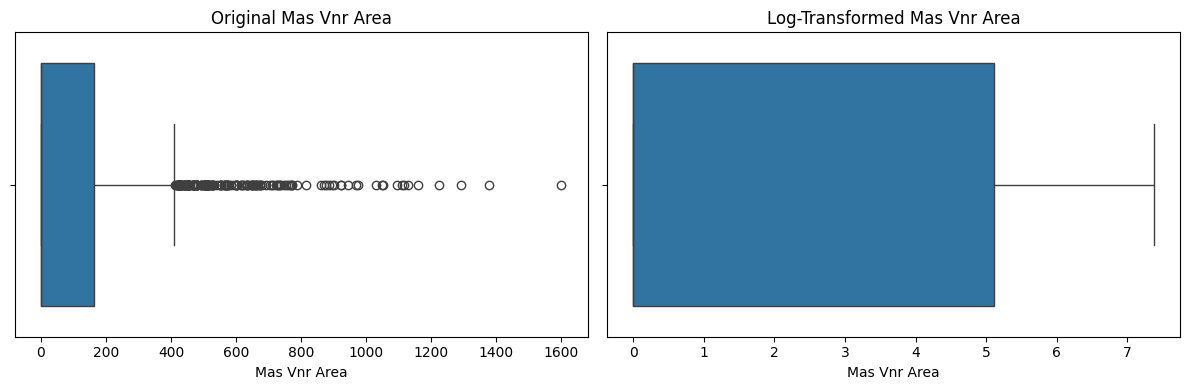

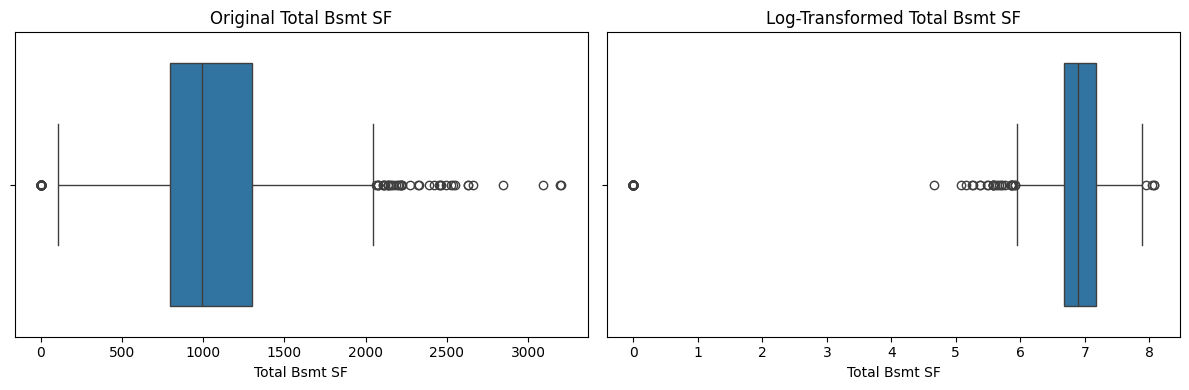

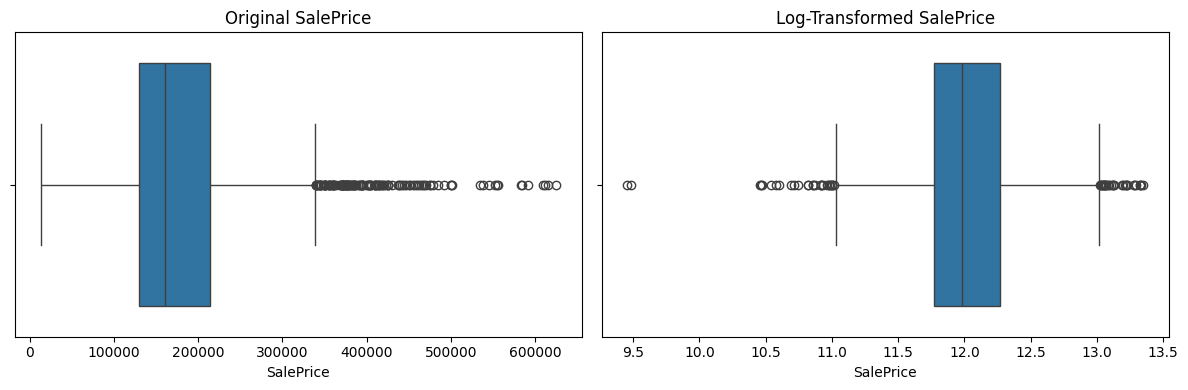

In [57]:
# we are about to do log transforms on columns with missing values
# the code below will handle this situation, but throws warnings
# I've temporarily suppressed these warnings as we know what is happening
import warnings

skewed_cols = ['Lot Area', 'Gr Liv Area', 'Mas Vnr Area', 'Total Bsmt SF', 'SalePrice']

# Temporarily ignore RuntimeWarning for log operations
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    for col in skewed_cols:
        fig, axs = plt.subplots(1, 2, figsize=(12, 4)) # Create a figure with two subplots

        sns.boxplot(data=df, x=col, ax=axs[0])
        axs[0].set_title(f'Original {col}')

        # Apply log1p for columns that can have zero values, log for others
        if col in ['Mas Vnr Area', 'Total Bsmt SF']:
            df[col] = np.log1p(df[col])
        else:
            df[col] = np.log(df[col])

        sns.boxplot(data=df, x=col, ax=axs[1])
        axs[1].set_title(f'Log-Transformed {col}')

        plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
        plt.show()

For an inference-focused regression analysis, it is generally appropriate to apply the log transformation to the entire analytic dataset.

That’s because a log transform is usually treated as part of variable definition/model specification,
and is not a learned preprocessing step. The log transform doesn't used the data to estimate anything (e.g., the way a median replacement would) so there is not concern with data leakage).





## Consistent units/scales

Making sure variables are measured coherently.

### Examples
- Mixing pounds and kilograms
- Annual income mixed with monthly income
- Percentages coded as:
  - `0–100`
  - and elsewhere as `0–1`

### Why it matters
Inconsistent scales can create nonsense coefficients and unstable models.

### Remediation:
Sometimes predictors are standardized. In particular, we will often to covert to z-scores when doing regression. This is not required for OLS, but can help with interpretation, comparison of effect sizes, numerical stability.

Important note: Scaling does **not** fix multicollinearity fundamentally, though centering can help with interaction/polynomial terms.

---

## Handling impossible values

Checking whether observations violate logical or physical constraints.

### Examples
- Negative age
- GPA > 4.0 (if impossible in system)
- Blood pressure = 0 for living patient
- Survey response outside allowed range

### Why it matters
Impossible values often indicate data corruption, coding mistakes, merge errors.

### Common remediation methods
- Rule-based validation
- Range checks
- Cross-variable consistency checks


---



## Cleaning Specifically with MLR in Mind
Preparing data specifically for multiple linear regression (MLR)  requires strict adherence to the algorithm’s statistical assumptions.
* Because MLR relies on ordinary least squares (OLS) optimization, it is highly sensitive to missing values and extreme outliers, both of which can disproportionately pull the line of best fit and must be carefully imputed, capped, or removed.
* Since the MLR equation requires strictly numeric inputs, categorical data must be converted into binary flags using one-hot encoding, with the critical step of dropping one baseline category to avoid the "dummy variable trap" (perfect multicollinearity).
* Mitigating multicollinearity is a primary focus of MLR
cleaning. We routinely use Variance Inflation Factor (VIF) scores to
identify and remove highly correlated overlapping predictors that would
otherwise cause the model's coefficient estimates to become wildly unstable and
meaningless.
* Applying mathematical transformations (such as logarithmic
scaling) to highly skewed variables helps satisfy the strict assumptions of
linearity and homoscedasticity, ensuring the final model is not just
mathematically functional, but statistically valid and interpretable.


## Phase 1: Structural Fixes & Semantic Cleaning (Pre-Split)
*These steps are deterministic (they don't rely on dataset statistics) and can safely be done on the whole dataset before splitting.*

In [58]:


# 3. Resolve "Meaningful" NAs
# Basement NAs mean "No Basement"
bsmt_cols = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']
for col in bsmt_cols:
    df[col] = df[col].fillna('None')

# Garage NAs mean "No Garage"
garage_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']
for col in garage_cols:
    df[col] = df[col].fillna('None')

# Fireplace NAs mean "No Fireplace"
df['Fireplace Qu'] = df['Fireplace Qu'].fillna('None')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 66 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MS SubClass     2925 non-null   object 
 1   MS Zoning       2925 non-null   object 
 2   Lot Frontage    2435 non-null   float64
 3   Lot Area        2925 non-null   float64
 4   Lot Shape       2925 non-null   object 
 5   Land Contour    2925 non-null   object 
 6   Lot Config      2925 non-null   object 
 7   Land Slope      2925 non-null   object 
 8   Neighborhood    2925 non-null   object 
 9   Condition 1     2925 non-null   object 
 10  Bldg Type       2925 non-null   object 
 11  House Style     2925 non-null   object 
 12  Overall Qual    2925 non-null   int64  
 13  Overall Cond    2925 non-null   int64  
 14  Year Built      2925 non-null   int64  
 15  Year Remod/Add  2925 non-null   int64  
 16  Roof Style      2925 non-null   object 
 17  Exterior 1st    2925 non-null   object

## Phase 2: The Golden Rule (Train/Test Split)
Before calculating any statistics, computing averages, or scaling data, we must split our data into training and test sets. Everything from this point forward must be learned *only* from the training set to prevent future data from leaking into your model.

In [59]:
# 4. Train/Test Split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

print(f"Training set: {df_train.shape}")
print(f"Test set: {df_test.shape}")

Training set: (2340, 66)
Test set: (585, 66)


## Phase 3: Handling Missing and Extreme Values (Train-Set Only)
Now we handle extreme outliers and true missing values. The dataset creator explicitly recommends removing houses with over 4,000 sq ft living area, as they represent unusual sales that skew OLS regression.

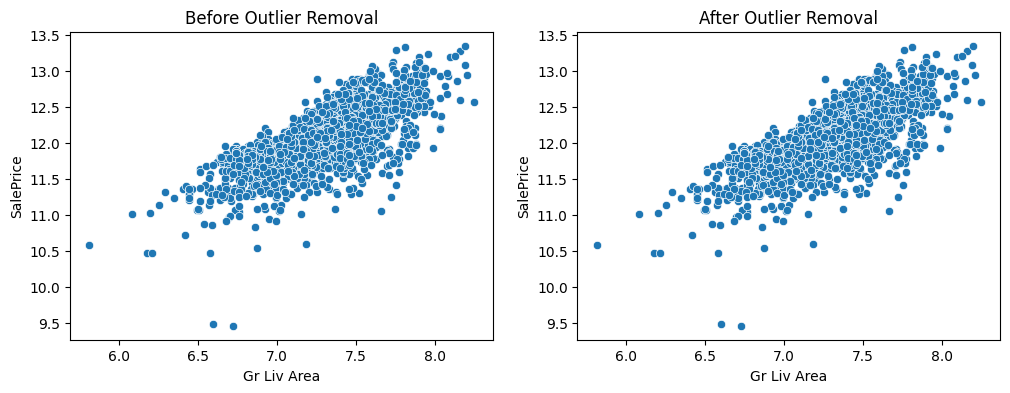

In [60]:
# 5. Remove Extreme Outliers (Train set only)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df_train['Gr Liv Area'], y=df_train['SalePrice'], ax=ax[0])
ax[0].set_title("Before Outlier Removal")

df_train = df_train[df_train['Gr Liv Area'] <= 4000].copy()

sns.scatterplot(x=df_train['Gr Liv Area'], y=df_train['SalePrice'], ax=ax[1])
ax[1].set_title("After Outlier Removal")
plt.show()

In [61]:
# 6. Statistical Imputation
from sklearn.impute import SimpleImputer

# Identify numeric columns for imputation
numeric_cols = df_train.select_dtypes(include=np.number).columns

# Use SimpleImputer to learn medians from train and apply to both train and test.
# This prevents crashes if a missing value appears in test data but not train data!
imputer = SimpleImputer(strategy='median')

# Fit on training data ONLY, then transform both
df_train[numeric_cols] = imputer.fit_transform(df_train[numeric_cols])
df_test[numeric_cols] = imputer.transform(df_test[numeric_cols])

## Phase 4: Feature Engineering & Transformations
MLR assumes a linear relationship. We can use log transformations on heavily skewed variables like SalePrice. We can also combine related features to reduce dimensionality.

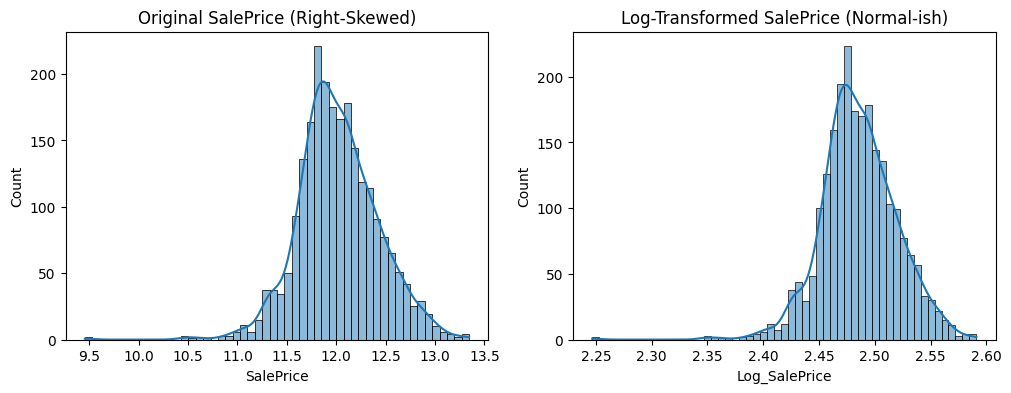

In [62]:
# 7. Transform Skewed Variables
df_train['Log_SalePrice'] = np.log(df_train['SalePrice'])
df_test['Log_SalePrice'] = np.log(df_test['SalePrice'])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_train['SalePrice'], ax=ax[0], kde=True)
ax[0].set_title('Original SalePrice (Right-Skewed)')
sns.histplot(df_train['Log_SalePrice'], ax=ax[1], kde=True)
ax[1].set_title('Log-Transformed SalePrice (Normal-ish)')
plt.show()

# Drop the original SalePrice so the model doesn't use it
df_train = df_train.drop('SalePrice', axis=1)
df_test = df_test.drop('SalePrice', axis=1)

In [63]:
# 8. Create Synergistic Features
df_train['Total_Square_Footage'] = df_train['1st Flr SF'] + df_train['2nd Flr SF'] + df_train['Total Bsmt SF']
df_test['Total_Square_Footage'] = df_test['1st Flr SF'] + df_test['2nd Flr SF'] + df_test['Total Bsmt SF']

# Drop the components to avoid multicollinearity
df_train = df_train.drop(['1st Flr SF', '2nd Flr SF', 'Total Bsmt SF'], axis=1)
df_test = df_test.drop(['1st Flr SF', '2nd Flr SF', 'Total Bsmt SF'], axis=1)

## Phase 5: Encoding for the Algorithm
Because MLR requires strict numeric inputs, we must translate text to math. We use Ordinal Encoding for ranked variables, and One-Hot Encoding (Nominal) for unranked variables.

In [64]:
# 9. Ordinal Encoding
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_cols = ['Exter Qual', 'Kitchen Qual', 'Heating QC', 'Bsmt Qual', 'Fireplace Qu']

for col in ordinal_cols:
    df_train[col] = df_train[col].map(quality_map).fillna(3) # TA is typical/average
    df_test[col] = df_test[col].map(quality_map).fillna(3)

# Garage Finish has a different mapping
garage_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
df_train['Garage Finish'] = df_train['Garage Finish'].map(garage_map).fillna(0)
df_test['Garage Finish'] = df_test['Garage Finish'].map(garage_map).fillna(0)

In [65]:
# 10. Nominal Encoding (One-Hot)
from sklearn.preprocessing import OneHotEncoder

# Select all remaining categorical columns to prevent the "Categorical Massacre"
# This retains valuable info like Sale Condition
nominal_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Encoding nominal columns: {nominal_cols}")

# Initialize OneHotEncoder.
# drop='first' avoids the dummy variable trap.
# handle_unknown='ignore' gracefully handles unseen categories in the test set without crashing.
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Fit on train and transform both
encoded_train = encoder.fit_transform(df_train[nominal_cols])
encoded_test = encoder.transform(df_test[nominal_cols])

# Get new feature names
encoded_cols = encoder.get_feature_names_out(nominal_cols)

# Create dataframes with encoded columns
df_encoded_train = pd.DataFrame(encoded_train, columns=encoded_cols, index=df_train.index)
df_encoded_test = pd.DataFrame(encoded_test, columns=encoded_cols, index=df_test.index)

# Drop original nominal columns and join encoded ones
df_train = df_train.drop(nominal_cols, axis=1).join(df_encoded_train)
df_test = df_test.drop(nominal_cols, axis=1).join(df_encoded_test)

Encoding nominal columns: ['MS SubClass', 'MS Zoning', 'Lot Shape', 'Land Contour', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Bldg Type', 'House Style', 'Roof Style', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Cond', 'Foundation', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Central Air', 'Electrical', 'Functional', 'Garage Type', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition']


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 11, 12] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Phase 6: Multicollinearity Check
If two independent variables are highly correlated (e.g., GarageCars and GarageArea), they confuse the model. We can run a Variance Inflation Factor (VIF) check or examine correlation directly.

In [66]:
# 11. Multicollinearity Check
print("Correlation between Garage Cars and Garage Area:",
      df_train['Garage Cars'].corr(df_train['Garage Area']))

corr_with_price = df_train[['Garage Cars', 'Garage Area', 'Log_SalePrice']].corr()['Log_SalePrice']
print("\nCorrelation with Log_SalePrice:")
print(corr_with_price)

# Because they are highly correlated (~0.89), we drop the one less correlated with Log_SalePrice (Garage Area)
df_train = df_train.drop('Garage Area', axis=1)
df_test = df_test.drop('Garage Area', axis=1)

Correlation between Garage Cars and Garage Area: 0.8892613603658601

Correlation with Log_SalePrice:
Garage Cars      0.661799
Garage Area      0.634010
Log_SalePrice    1.000000
Name: Log_SalePrice, dtype: float64


## Phase 7: Target Variable Housekeeping
We've beautifully transformed SalePrice to Log_SalePrice, but it's still sitting inside our feature sets. If we passed this directly into a model, the algorithm would use Log_SalePrice to predict Log_SalePrice! We must separate our features (X) and target (y).

In [67]:
# 12. Separate Features (X) and Target (y)
X_train = df_train.drop('Log_SalePrice', axis=1)
y_train = df_train['Log_SalePrice']

X_test = df_test.drop('Log_SalePrice', axis=1)
y_test = df_test['Log_SalePrice']

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (2340, 224), y_train shape: (2340,)
X_test shape: (585, 224), y_test shape: (585,)


## Summary
By following this order—**Structure → Split → Impute → Transform → Encode → Prune → Separate Target**—we ensured that our model remains statistically pure (no data leakage), retains its valuable signals (proper encoding), and respects the strict mathematical boundaries of Multiple Linear Regression (no multicollinearity or outliers).

### Where This Work Goes Next
All of the cleaning steps we walked through here have been packaged into a reusable module called `ames_cleaning.py`. In Part 2, we will load that module and call `load_and_clean_ames()`, which applies every decision we just made, so we can focus on building and evaluating models without re-running all of this cleaning code. The function exists to keep the modeling notebooks focused, but everything it does is exactly what we practiced here.